<a href="https://colab.research.google.com/github/AnanyaUp/ANN-Deep-Learning/blob/main/GradCAM_on_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Grad-CAM**


In [ ]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self._to_linear = None

        self._get_flatten_size()

        self.fc1 = nn.Linear(self._to_linear, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def _get_flatten_size(self):
        with torch.no_grad():
            x = torch.randn(1, 3, 256, 256)
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        self.feature_maps = self.pool(F.relu(self.conv2(x)))
        x = self.feature_maps.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        gradients = self.gradients
        activations = self.activations

        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
        for i in range(activations.shape[1]):
            activations[:, i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().numpy(), class_idx

In [ ]:
def show_gradcam(image_tensor, heatmap, label, pred_class, class_names):
    image_np = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    image_np = image_np * 0.125 + 0.5  # Unnormalize
    image_np = np.clip(image_np, 0, 1)

    heatmap_resized = cv2.resize(heatmap, (image_np.shape[1], image_np.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = np.float32(heatmap_colored) / 255
    superimposed = heatmap_colored[..., ::-1] + image_np
    superimposed = superimposed / superimposed.max()

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed)
    plt.title(f"True: {class_names[label]} | Predicted: {class_names[pred_class]}")
    plt.axis("off")
    plt.show()

In [ ]:
def train_model(model, dataloader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss/len(dataloader):.4f}")
    print("Training complete!")

In [ ]:
#Model and target layer
model = SimpleCNN(num_classes=2)
target_layer = model.conv2

grad_cam = GradCAM(model,target_layer)

In [ ]:
import sys
sys.path.append('/content/dataloader.py')

Mounted at /content/drive
Batch size: torch.Size([64, 3, 256, 256]), Labels: tensor([1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
        0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1])


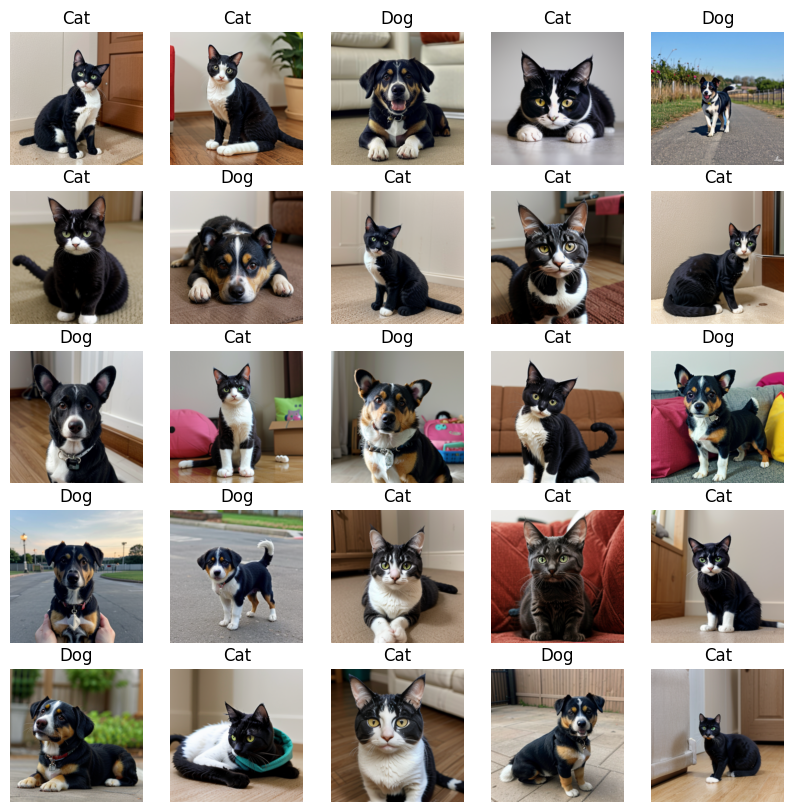

In [ ]:
#import dataset from file DataLoader
from dataloader import CatsDogsDataset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

In [ ]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

In [ ]:
#Execution
#dataset and dataloader
dataset_path = '/content/drive/MyDrive/animals'
class_names = ['cat', 'dog']
dataset = CatsDogsDataset(dataset_path, transform=transform)

# Split dataset
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Initialize Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=len(class_names)).to(device)

train_model(model, train_loader, epochs=5)


Epoch 1/5: 100%|██████████| 24/24 [04:09<00:00, 10.40s/it]


Epoch 1 Loss: 0.9814


Epoch 2/5: 100%|██████████| 24/24 [01:08<00:00,  2.86s/it]


Epoch 2 Loss: 0.4992


Epoch 3/5: 100%|██████████| 24/24 [01:08<00:00,  2.84s/it]


Epoch 3 Loss: 0.3773


Epoch 4/5: 100%|██████████| 24/24 [01:08<00:00,  2.86s/it]


Epoch 4 Loss: 0.2599


Epoch 5/5: 100%|██████████| 24/24 [01:08<00:00,  2.85s/it]

Epoch 5 Loss: 0.1584
Training complete!


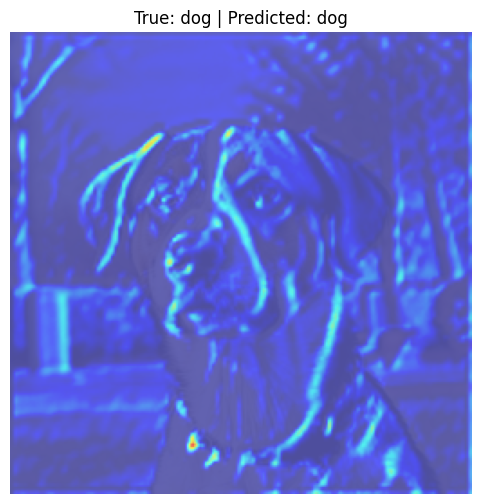

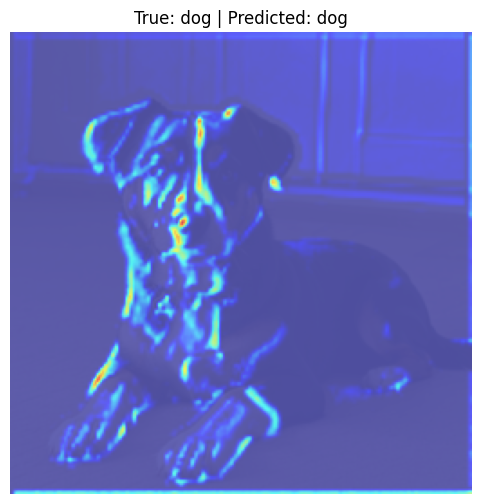

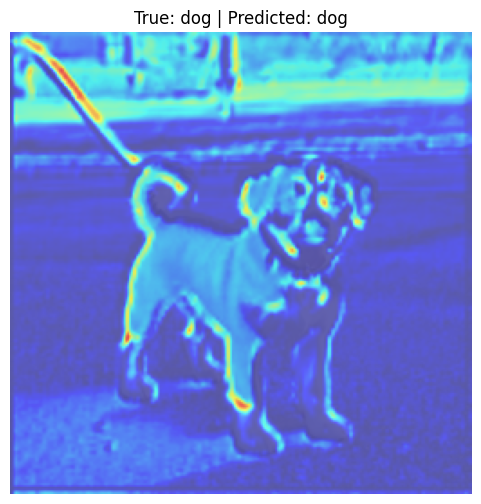

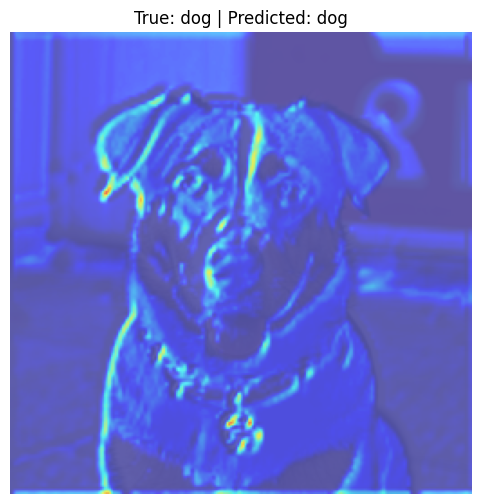

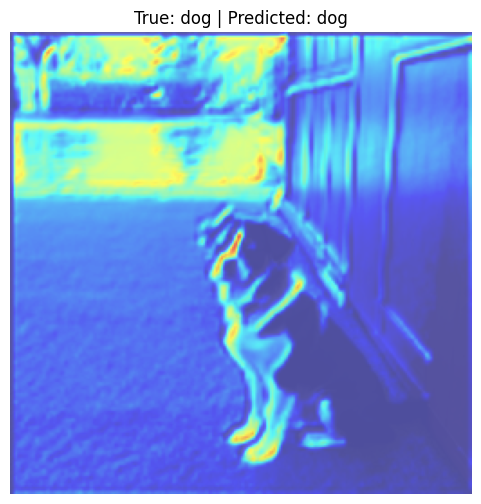


 Test Accuracy: 88.95%


In [ ]:
# Initialize GradCAM
gradcam = GradCAM(model, model.conv2)

# Testing
model.eval()
correct = 0
total = 0

for image_tensor, label in test_loader:
    input_tensor = image_tensor.to(device)

    # Run through model *with* gradients for Grad-CAM
    output = model(input_tensor)
    pred = output.argmax(dim=1).item()

    total += 1
    correct += (pred == label.item())

    # Run Grad-CAM on first 5 examples
    if total <= 5:
        heatmap, _ = gradcam.generate(input_tensor, class_idx=pred)
        show_gradcam(image_tensor, heatmap, label.item(), pred, class_names)

accuracy = correct / total * 100
print(f"\n Test Accuracy: {accuracy:.2f}%")
